<a href="https://colab.research.google.com/github/JorgeCarmona323/CHEM_280_Final_Project/blob/main/colab/NB01_ConformerEnsemble/01_TauK18_Conformer_Ensemble_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Starling → AFRC Filter → FoldMason Pipeline

End-to-end IDP ensemble generation and conformer selection in one notebook.

**Requires**: GPU runtime (`Runtime > Change runtime type > T4 GPU`)

## What this notebook does
1. Runs **Starling** on a trimmed IDP sequence → conformer ensemble
2. Applies **AFRC** Rg filter (sequence-specific random coil reference) + deviation maps
3. Runs **FoldMason** on filtered frames → structural MSA + 3Di tokens + lDDT
4. Ranks conformers by lDDT + epitope structural content → `_binder_ready/`
5. Downloads everything as a single zip

**Output**: top 3–5 conformers ready for RFDiffusion / BindCraft / Forge

## 0. Check GPU

In [29]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU — switch to GPU runtime')

Mon Mar 16 05:36:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [30]:
# ── Google Drive Setup ────────────────────────────────────────────────────────
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = '/content/drive/MyDrive/CHEM_280'
    _in_drive  = True
    print(f'Drive mounted. Base: {DRIVE_BASE}')
except Exception:
    DRIVE_BASE = '/content'
    _in_drive  = False
    print('Drive not available — saving to /content/')

# Override output directory to use Drive (so results survive session end)
NB01_OUT = os.path.join(DRIVE_BASE, 'results', 'nb01_output')
os.makedirs(NB01_OUT, exist_ok=True)
print(f'NB01 output dir: {NB01_OUT}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Base: /content/drive/MyDrive/CHEM_280
NB01 output dir: /content/drive/MyDrive/CHEM_280/results/nb01_output


## 1. Install dependencies

In [31]:
!pip install -q idptools-starling MDAnalysis afrc

# FoldMason — precompiled binary (no conda needed on Colab)
import os, sys
if not os.path.exists('/content/foldmason/bin/foldmason'):
    !wget -q https://mmseqs.com/foldmason/foldmason-linux-avx2.tar.gz
    !tar xzf foldmason-linux-avx2.tar.gz -C /content/
    !rm foldmason-linux-avx2.tar.gz
    !chmod +x /content/foldmason/bin/foldmason

# Ensure pip-installed scripts are on PATH in this session
pip_bin = os.path.join(sys.prefix, 'bin')
if pip_bin not in os.environ['PATH']:
    os.environ['PATH'] = pip_bin + ':' + os.environ['PATH']
local_bin = os.path.expanduser('~/.local/bin')
if local_bin not in os.environ['PATH']:
    os.environ['PATH'] = local_bin + ':' + os.environ['PATH']

In [32]:
import subprocess
import os, sys, glob, shutil, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
from afrc import AnalyticalFRC

FM_BIN = '/content/foldmason/bin/foldmason'

print('FoldMason  :', FM_BIN)
print('MDAnalysis :', mda.__version__)
print('AFRC       : OK')
print('numpy      :', np.__version__)

r = subprocess.run(['starling', '--help'], capture_output=True, text=True)
print('Starling   :', 'OK' if r.returncode == 0 else 'MISSING')

FoldMason  : /content/foldmason/bin/foldmason
MDAnalysis : 2.10.0
AFRC       : OK
numpy      : 2.0.2
Starling   : OK


In [33]:
r = subprocess.run([FM_BIN, 'version'], capture_output=True, text=True)
print('FoldMason:', r.stdout.strip()[:60])

r2 = subprocess.run(['starling', '--help'], capture_output=True, text=True)
print('Starling :', 'OK' if r2.returncode == 0 else r2.stderr[:80])

FoldMason: 4bd8b8d8c20d439b52ff8a3fccc50a3aba2be286
Starling : OK


## 2. Configuration

Edit this cell only. Everything else runs automatically.

In [34]:
# ── EDIT THESE ──────────────────────────────────────────────────────────────

PROTEIN_NAME  = 'tau_k18'
N_CONFORMERS  = 400          # 100 = exploration | 400 = production

# Trimmed IDP sequence — disordered region only (no structured domains)
# Tau K18 repeat domain (MTBR R1–R4, residues 244–368, 2N4R numbering)
SEQUENCE = (
    'KVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGG'
    'QVEVKSEKLDFKDRVQSKIGSLDNITHVPGGGNKKIETHKLTFRENAKAKTDHGAEIVYKSPV'
    'VSGDTSPRHLSNVSSTGSIDMVDSPQLATLADEVSASLAKQGL'
)

# Epitope residue ranges (1-indexed positions in SEQUENCE)
# Format: (start, end, label, weight)
#
# Weights reflect scientific priority from Sugiyama et al. 2025:
#   PHF6* / PHF6 = primary aggregation drivers (highest Writhe signal)
#   jR2R3        = counterstrand anchor that holds PHF6 in place;
#                  weighted 0.5 so its 19 residues don't dominate scoring
#
# K18 1-indexed positions (2N4R residue = K18 pos + 243):
#   PHF6*  : 2N4R 275–280  → K18  2–7
#   PHF6   : 2N4R 306–311  → K18 33–38  (note: seq shows VQIVYK at 33–38 ✓)
#   jR2R3  : 2N4R 295–313  → K18 52–70  (19-aa counterstrand, Sugiyama 2025)
EPITOPE_RANGES = [
    (2,  7,  'PHF6* VQIINK', 1.0),
    (33, 38, 'PHF6 VQIVYK',  1.0),
    (52, 70, 'jR2R3',         0.5),
]

# FoldMason conformer selection
TOP_N          = 5    # conformers to keep for binder design
LDDT_WEIGHT    = 0.6
EPITOPE_WEIGHT = 0.4

# ─────────────────────────────────────────────────────────────────────────────

# Flat list of 0-indexed positions for AFRC deviation plot shading
epitope_positions = []
for start, end, label, *_ in EPITOPE_RANGES:
    epitope_positions.extend(range(start - 1, end))

print(f'Protein    : {PROTEIN_NAME}')
print(f'Length     : {len(SEQUENCE)} aa')
print(f'Conformers : {N_CONFORMERS}')
print(f'Top N      : {TOP_N}')
print()
print('Epitope verification:')
for start, end, label, weight in EPITOPE_RANGES:
    print(f'  {label:20s} pos {start:3d}–{end:3d}  weight={weight}  seq={SEQUENCE[start-1:end]}')

Protein    : tau_k18
Length     : 168 aa
Conformers : 400
Top N      : 5

Epitope verification:
  PHF6* VQIINK         pos   2–  7  weight=1.0  seq=VQIINK
  PHF6 VQIVYK          pos  33– 38  weight=1.0  seq=VQIVYK
  jR2R3                pos  52– 70  weight=0.5  seq=LGNIHHKPGGGQVEVKSEK


## 3. Run Starling

Generates a conformational ensemble for the IDP sequence.

Outputs: `{PROTEIN_NAME}_STARLING.pdb` (topology) + `_STARLING.xtc` (trajectory)

In [35]:
import os
# Use Drive output dir if mounted, otherwise /content/output
_nb01_out = str(NB01_OUT)
os.makedirs(_nb01_out, exist_ok=True)
%cd {_nb01_out}
print(f'Working dir: {_nb01_out}')


/content/drive/MyDrive/CHEM_280/results/nb01_output
Working dir: /content/drive/MyDrive/CHEM_280/results/nb01_output


In [36]:
cmd = f'starling {SEQUENCE} --outname {PROTEIN_NAME} -c {N_CONFORMERS} -r'
print(f'Running: {cmd[:80]}...\n')
!{cmd}

Running: starling KVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKL...

Using DDIM sampler
Progress through sequences:   0% 0/1 [00:00<?, ?it/s]
DDIM steps (batch 1 of 4):   0% 0/31 [00:00<?, ?it/s]
DDIM steps (batch 1 of 4):   3% 1/31 [00:00<00:12,  2.37it/s]
DDIM steps (batch 1 of 4):   6% 2/31 [00:00<00:08,  3.26it/s]
DDIM steps (batch 1 of 4):  10% 3/31 [00:00<00:07,  3.67it/s]
DDIM steps (batch 1 of 4):  13% 4/31 [00:01<00:06,  3.88it/s]
DDIM steps (batch 1 of 4):  16% 5/31 [00:01<00:06,  4.01it/s]
DDIM steps (batch 1 of 4):  19% 6/31 [00:01<00:06,  4.10it/s]
DDIM steps (batch 1 of 4):  23% 7/31 [00:01<00:05,  4.14it/s]
DDIM steps (batch 1 of 4):  26% 8/31 [00:02<00:05,  4.18it/s]
DDIM steps (batch 1 of 4):  29% 9/31 [00:02<00:05,  4.21it/s]
DDIM steps (batch 1 of 4):  32% 10/31 [00:02<00:04,  4.22it/s]
DDIM steps (batch 1 of 4):  35% 11/31 [00:02<00:04,  4.23it/s]
DDIM steps (batch 1 of 4):  39% 12/31 [00:02<00:04,  4.24it/s]
DDIM steps (batch 1 of 4):  42% 

In [37]:
pdb_file = f'{PROTEIN_NAME}_STARLING.pdb'
xtc_file = f'{PROTEIN_NAME}_STARLING.xtc'
assert os.path.exists(pdb_file), f'Missing: {pdb_file}'
assert os.path.exists(xtc_file), f'Missing: {xtc_file}'
print(f'PDB : {pdb_file}  ({os.path.getsize(pdb_file)//1024} KB)')
print(f'XTC : {xtc_file}  ({os.path.getsize(xtc_file)//1024} KB)')

PDB : tau_k18_STARLING.pdb  (13 KB)
XTC : tau_k18_STARLING.xtc  (313 KB)


## 4. Extract PDB frames

In [38]:
def extract_frames(topology, trajectory, output_dir, n_frames=100):
    os.makedirs(output_dir, exist_ok=True)
    u = mda.Universe(topology, trajectory)
    total   = len(u.trajectory)
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    saved   = []
    for i, ts_idx in enumerate(indices):
        u.trajectory[ts_idx]
        out = os.path.join(output_dir, f'frame_{i+1:04d}.pdb')
        u.atoms.write(out)
        saved.append(out)
    print(f'Extracted {len(saved)} frames → {output_dir}/')
    return saved

frames_dir = os.path.abspath(f'{PROTEIN_NAME}_frames')
frames     = extract_frames(pdb_file, xtc_file, frames_dir, n_frames=N_CONFORMERS)
print(f'First frame: {frames[0]}')

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


Extracted 400 frames → /content/drive/MyDrive/CHEM_280/results/nb01_output/tau_k18_frames/
First frame: /content/drive/MyDrive/CHEM_280/results/nb01_output/tau_k18_frames/frame_0001.pdb


## 5. AFRC Filter + Deviation Maps

Computes ensemble Rg distribution, compares to the AFRC analytical random-coil reference,
filters to ±2σ, and builds fractional-deviation distance maps.

AFRC reference (168 aa):  Rg=32.3 Å   Re=75.4 Å
Building AFRC distance map (analytical, ~15s)...
Done.
Extracted frames: 400


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


Rg mean=41.7  std=8.2 Å  |  AFRC ref=32.3 Å
Passing ±2σ: 385/400


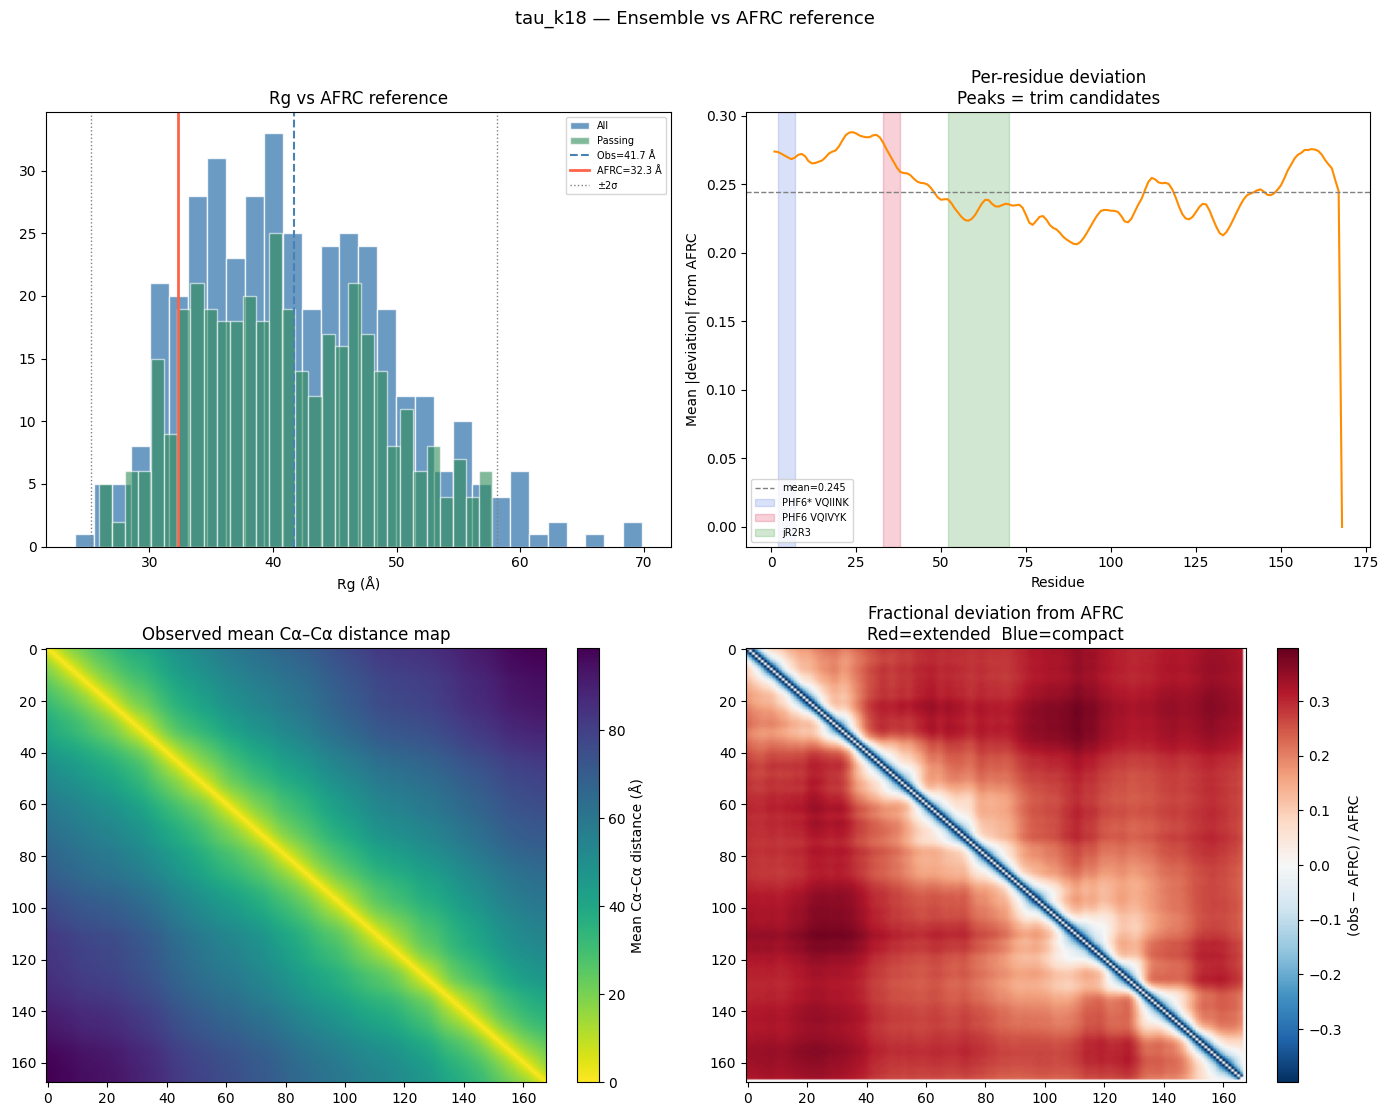

Saved ensemble_analysis.png


In [39]:
import matplotlib.pyplot as plt
import re
from collections import Counter

# ── AFRC reference state ─────────────────────────────────────────────────────
afrc    = AnalyticalFRC(SEQUENCE)
rg_afrc = afrc.get_mean_radius_of_gyration()
re_afrc = afrc.get_mean_end_to_end_distance()
print(f'AFRC reference ({len(SEQUENCE)} aa):  Rg={rg_afrc:.1f} Å   Re={re_afrc:.1f} Å')

# Build NxN mean distance map.
# AFRC uses 1-indexed residues capped at N-1 (bond indexing: N residues → N-1 bonds).
print('Building AFRC distance map (analytical, ~15s)...')
n = len(SEQUENCE)
afrc_dist = np.zeros((n, n))
for i in range(1, n):           # 1 … N-1
    for j in range(i + 1, n):  # i+1 … N-1
        bins, p_r = afrc.get_interresidue_distance_distribution(i, j)
        bins  = np.array(bins)
        p_r   = np.array(p_r)
        p_r   = p_r / p_r.sum()          # normalize to proper PMF
        mean_d = float(np.dot(bins, p_r))
        afrc_dist[i - 1, j - 1] = mean_d
        afrc_dist[j - 1, i - 1] = mean_d
print('Done.')

# ── Load Rg from extracted PDB files ─────────────────────────────────────────
frame_files   = sorted(glob.glob(os.path.join(frames_dir, 'frame_*.pdb')))
n_frames_traj = len(frame_files)
print(f'Extracted frames: {n_frames_traj}')

rg_all, ca_arrays = [], []
n_residues = None
for fn in frame_files:
    u_f  = mda.Universe(fn)
    ca_f = u_f.select_atoms('name CA')
    if n_residues is None:
        n_residues = len(ca_f)
    rg_all.append(ca_f.radius_of_gyration())
    ca_arrays.append(ca_f.positions.copy())

rg_all = np.array(rg_all)

# ── Rg filter (±2σ) ──────────────────────────────────────────────────────────
rg_mean, rg_std = rg_all.mean(), rg_all.std()
rg_lo, rg_hi    = rg_mean - 2 * rg_std, rg_mean + 2 * rg_std
keep_idx        = np.where((rg_all >= rg_lo) & (rg_all <= rg_hi))[0]
print(f'Rg mean={rg_mean:.1f}  std={rg_std:.1f} Å  |  AFRC ref={rg_afrc:.1f} Å')
print(f'Passing ±2σ: {len(keep_idx)}/{n_frames_traj}')

# ── Observed mean Cα distance map (passing frames only) ──────────────────────
positions = np.array([ca_arrays[i] for i in keep_idx])
obs_dist  = np.zeros((n_residues, n_residues))
for k in range(len(positions)):
    diff      = positions[k][:, None, :] - positions[k][None, :, :]
    obs_dist += np.linalg.norm(diff, axis=-1)
obs_dist /= len(positions)

# ── Fractional deviation from AFRC ───────────────────────────────────────────
ad = afrc_dist[:n_residues, :n_residues]
with np.errstate(invalid='ignore', divide='ignore'):
    deviation = np.where(ad > 0, (obs_dist - ad) / ad, 0.0)
np.fill_diagonal(deviation, 0)
marginal_dev = np.abs(deviation).mean(axis=1)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
epi_colors = {'PHF6* VQIINK': 'royalblue', 'PHF6 VQIVYK': 'crimson', 'jR2R3': 'forestgreen'}

ax = axes[0, 0]
ax.hist(rg_all, bins=30, color='steelblue', edgecolor='white', alpha=0.8, label='All')
ax.hist(rg_all[keep_idx], bins=30, color='seagreen', edgecolor='white', alpha=0.6, label='Passing')
ax.axvline(rg_mean, color='steelblue', ls='--', lw=1.5, label=f'Obs={rg_mean:.1f} Å')
ax.axvline(rg_afrc, color='tomato',    ls='-',  lw=2,   label=f'AFRC={rg_afrc:.1f} Å')
ax.axvline(rg_lo, color='gray', ls=':', lw=1); ax.axvline(rg_hi, color='gray', ls=':', lw=1, label='±2σ')
ax.set_xlabel('Rg (Å)'); ax.set_title('Rg vs AFRC reference'); ax.legend(fontsize=7)

ax = axes[0, 1]
ax.plot(range(1, n_residues + 1), marginal_dev, color='darkorange', lw=1.5)
ax.axhline(marginal_dev.mean(), color='gray', ls='--', lw=1, label=f'mean={marginal_dev.mean():.3f}')
for start, end, label, *_ in EPITOPE_RANGES:
    ax.axvspan(start, end, alpha=0.2, color=epi_colors.get(label, 'gray'), label=label)
ax.set_xlabel('Residue'); ax.set_ylabel('Mean |deviation| from AFRC')
ax.set_title('Per-residue deviation\nPeaks = trim candidates'); ax.legend(fontsize=7)

ax = axes[1, 0]
im = ax.imshow(obs_dist, cmap='viridis_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Cα–Cα distance (Å)')
ax.set_title('Observed mean Cα–Cα distance map')

ax = axes[1, 1]
vmax = max(0.3, float(np.abs(deviation).max()) * 0.8)
im2  = ax.imshow(deviation, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=ax, label='(obs − AFRC) / AFRC')
ax.set_title('Fractional deviation from AFRC\nRed=extended  Blue=compact')

plt.suptitle(f'{PROTEIN_NAME} — Ensemble vs AFRC reference', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.abspath(f'{PROTEIN_NAME}_ensemble_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved ensemble_analysis.png')

## 6. Write filtered frames

In [40]:
filtered_dir = os.path.abspath(f'{PROTEIN_NAME}_frames_filtered')
os.makedirs(filtered_dir, exist_ok=True)

for rank, frame_idx in enumerate(keep_idx):
    src = frame_files[frame_idx]   # frame_files defined in cell-16 — correct index
    dst = os.path.join(filtered_dir, f'filtered_{rank+1:04d}.pdb')
    shutil.copy2(src, dst)

n_filtered = len(os.listdir(filtered_dir))
print(f'Filtered frames : {n_filtered} → {filtered_dir}/')
print(f'Dropped         : {n_frames_traj - len(keep_idx)} outlier conformers '
      f'({100*(n_frames_traj-len(keep_idx))/n_frames_traj:.1f}%)')

Filtered frames : 385 → /content/drive/MyDrive/CHEM_280/results/nb01_output/tau_k18_frames_filtered/
Dropped         : 15 outlier conformers (3.8%)


In [42]:
## 7. Run FoldMason
fm_msa_out = os.path.abspath(f'{PROTEIN_NAME}_foldmason_msa')
fm_msa_tmp = os.path.abspath(f'{PROTEIN_NAME}_foldmason_tmp')
os.makedirs(fm_msa_tmp, exist_ok=True)

pdb_files = sorted(glob.glob(os.path.join(filtered_dir, '*.pdb')))
if not pdb_files:
    raise FileNotFoundError(f'No PDBs found in {filtered_dir}')
print(f'Running FoldMason easy-msa on {len(pdb_files)} PDBs...')

# Fix: Ensure execute permissions for files in the temporary directory
# This addresses 'error 13: Permission denied' for dynamically created scripts
for root, dirs, files in os.walk(fm_msa_tmp):
    for d in dirs:
        os.chmod(os.path.join(root, d), 0o755) # drwxr-xr-x
    for f in files:
        os.chmod(os.path.join(root, f), 0o755) # -rwxr-xr-x

cmd = [FM_BIN, 'easy-msa', *pdb_files, fm_msa_out, fm_msa_tmp,
       '--report-mode', '2', '--threads', '2'] # Changed report-mode to 2 for JSON
r = subprocess.run(cmd, capture_output=True, text=True)
if r.returncode != 0:
    print(f'STDERR:\n{r.stderr[-600:]}')
    raise RuntimeError('FoldMason easy-msa failed')

msa_aa_path  = f'{fm_msa_out}_aa.fa'
msa_3di_path = f'{fm_msa_out}_3di.fa'
#html_path    = f'{fm_msa_out}.html' # HTML is no longer primary for lDDT
json_path    = f'{fm_msa_out}.json' # New path for JSON report

for label, path in [('AA MSA (_aa.fa)', msa_aa_path),
                    ('3Di MSA (_3di.fa)', msa_3di_path),
                    ('JSON report (.json)', json_path)]:
    print(f'  {label}: {"OK" if os.path.exists(path) else "MISSING"}')

Running FoldMason easy-msa on 385 PDBs...
  AA MSA (_aa.fa): OK
  3Di MSA (_3di.fa): OK
  JSON report (.json): OK


In [48]:
import re
from collections import Counter
import json # Import json module

def parse_fasta_msa(path):
    """Parse a FASTA-format MSA → dict {name: gapped_sequence}."""
    records = {}
    header, lines = None, []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.startswith('>'):
                if header is not None:
                    records[header] = ''.join(lines)
                header = line[1:].split()[0]
                lines = []
            else:
                lines.append(line)
    if header is not None:
        records[header] = ''.join(lines)
    return records

def compute_msa_consistency(records):
    """Fraction of non-gap positions matching column-wise consensus."""
    names = list(records.keys())
    seqs  = list(records.values())
    n_cols = len(seqs[0])
    consensus = []
    for col in range(n_cols):
        chars    = [s[col] for s in seqs if col < len(s)]
        non_gap  = [c for c in chars if c != '-']
        consensus.append(Counter(non_gap).most_common(1)[0][0] if non_gap else '-')
    scores = {}
    for name, seq in zip(names, seqs):
        matches = total = 0
        for char, cons in zip(seq, consensus):
            if char != '-' and cons != '-':
                total += 1
                if char == cons:
                    matches += 1
        scores[name] = matches / total if total > 0 else 0.0
    return scores, consensus

def parse_lddt_from_json(json_path):
    """Extract per-structure lDDT from FoldMason JSON report."""
    scores = {}
    if not os.path.exists(json_path):
        return scores
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)

        # Modified logic to correctly parse the JSON structure
        if 'entries' in data and 'scores' in data and \
           isinstance(data['entries'], list) and isinstance(data['scores'], list):
            entry_list = data['entries']
            lddt_list = data['scores']

            if len(entry_list) == len(lddt_list):
                for i in range(len(entry_list)):
                    entry = entry_list[i]
                    lddt_score = lddt_list[i]
                    name = entry.get('name')
                    if name:
                        scores[name] = lddt_score
            else:
                print(f"Warning: Mismatch in length of 'entries' ({len(entry_list)}) and 'scores' ({len(lddt_list)}) in JSON.")
        else:
            print("JSON does not contain expected 'entries' or 'scores' lists.")

    except json.JSONDecodeError:
        print(f"Error decoding JSON from {json_path}")
    return scores

# ── Parse all three outputs ───────────────────────────────────────────────────
aa_records  = parse_fasta_msa(msa_aa_path)
di_records  = parse_fasta_msa(msa_3di_path)
consistency_scores, aa_consensus = compute_msa_consistency(aa_records)
lddt_scores = parse_lddt_from_json(json_path) # Changed to parse from JSON

# Build column-wise 3Di consensus for epitope scoring
di_seqs_list = list(di_records.values())
n_cols_3di   = len(di_seqs_list[0]) if di_seqs_list else 0
di_consensus = []
for col in range(n_cols_3di):
    chars   = [s[col] for s in di_seqs_list if col < len(s)]
    non_gap = [c for c in chars if c != '-']
    di_consensus.append(Counter(non_gap).most_common(1)[0][0] if non_gap else '-')

print(f'AA MSA  : {len(aa_records)} conformers × {len(aa_consensus)} columns')
print(f'3Di MSA : {len(di_records)} conformers × {n_cols_3di} columns')
if lddt_scores:
    vals = list(lddt_scores.values())
    print(f'lDDT    : {len(lddt_scores)} conformers  '
          f'mean={np.mean(vals):.3f}  min={np.min(vals):.3f}  max={np.max(vals):.3f}')
else:
    print('lDDT    : not parsed from JSON — will rank by consistency + 3Di only')

AA MSA  : 385 conformers × 168 columns
3Di MSA : 385 conformers × 168 columns
lDDT    : not parsed from JSON — will rank by consistency + 3Di only


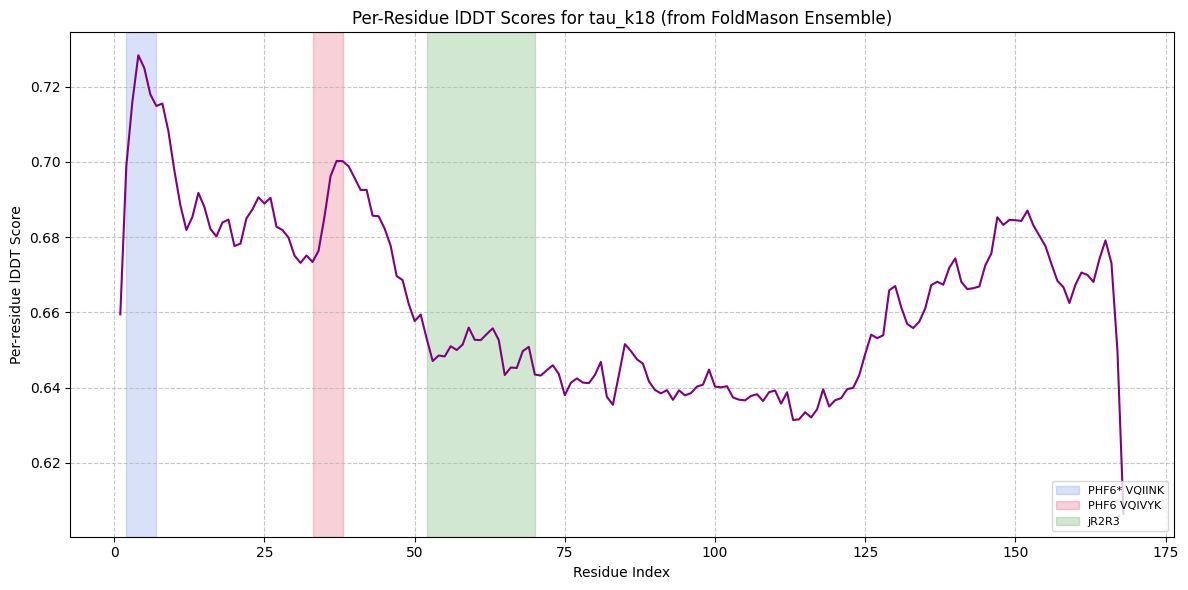

Displayed per-residue lDDT plot.
Saved per_residue_lddt.png


<Figure size 640x480 with 0 Axes>

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# Ensure json_path is defined from previous cells
# If it's not, you might need to run the FoldMason step again or define it.
# json_path = f'{PROTEIN_NAME}_foldmason_msa.json'

if os.path.exists(json_path):
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)

        per_residue_lddt = data.get('scores', [])

        if per_residue_lddt:
            num_residues = len(per_residue_lddt)
            residue_indices = np.arange(1, num_residues + 1) # 1-indexed for biological relevance

            plt.figure(figsize=(12, 6))
            plt.plot(residue_indices, per_residue_lddt, color='purple', linewidth=1.5)
            plt.xlabel('Residue Index')
            plt.ylabel('Per-residue lDDT Score')
            plt.title(f'Per-Residue lDDT Scores for {PROTEIN_NAME} (from FoldMason Ensemble)')
            plt.grid(True, linestyle='--', alpha=0.7)

            # Highlight epitope regions if EPITOPE_RANGES is available
            if 'EPITOPE_RANGES' in globals():
                epi_colors_map = {'PHF6* VQIINK': 'royalblue', 'PHF6 VQIVYK': 'crimson', 'jR2R3': 'forestgreen'}
                for start, end, label, *_ in EPITOPE_RANGES:
                    plt.axvspan(start, end, alpha=0.2, color=epi_colors_map.get(label, 'gray'), label=label)
                plt.legend(fontsize=8, loc='lower right')

            plt.tight_layout()
            plt.show()
            print('Displayed per-residue lDDT plot.')
            plt.savefig(os.path.abspath(f'{PROTEIN_NAME}_per_residue_lddt.png'), dpi=150, bbox_inches='tight')
            print('Saved per_residue_lddt.png')
        else:
            print("The 'scores' list in the JSON file is empty or not found.")

    except json.JSONDecodeError:
        print(f"Error decoding JSON from {json_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f"JSON file not found at {json_path}. Please ensure FoldMason was run correctly.")


## 8. Conformer Ranking

Ranks conformers by:
- **lDDT** (FoldMason) — how representative each conformer is of the ensemble average
- **Epitope structural content** — fraction of non-D 3Di states at defined binding sites

Combined score = `LDDT_WEIGHT × lDDT + EPITOPE_WEIGHT × epitope_struct`

In [50]:
# Verify epitope positions against one representative sequence
sample_name = list(aa_records.keys())[0]
sample_aa   = aa_records[sample_name].replace('-', '')

print(f'Conformers scored : {len(consistency_scores)}')
print(f'Sequence length (ungapped sample): {len(sample_aa)}  expected: {len(SEQUENCE)}')
print()
print('Epitope verification (from config SEQUENCE):')
for start, end, label, *_ in EPITOPE_RANGES:
    print(f'  {label:20s}  pos {start:3d}–{end:3d}  seq={SEQUENCE[start-1:end]}')
print()
cons_vals = list(consistency_scores.values())
print(f'MSA consistency : mean={np.mean(cons_vals):.3f}  '
      f'std={np.std(cons_vals):.3f}  '
      f'min={np.min(cons_vals):.3f}  max={np.max(cons_vals):.3f}')

Conformers scored : 385
Sequence length (ungapped sample): 168  expected: 168

Epitope verification (from config SEQUENCE):
  PHF6* VQIINK          pos   2–  7  seq=VQIINK
  PHF6 VQIVYK           pos  33– 38  seq=VQIVYK
  jR2R3                 pos  52– 70  seq=LGNIHHKPGGGQVEVKSEK

MSA consistency : mean=1.000  std=0.000  min=1.000  max=1.000


In [51]:
def epitope_3di_score(di_seq, di_cons):
    """
    Per-epitope 3Di column-conservation score.
    Score = fraction of epitope positions (non-gap) where the conformer's
    3Di token matches the column-wise consensus.  Weighted average across epitopes.
    """
    epi_fracs, epi_weights = [], []
    for start, end, label, weight in EPITOPE_RANGES:
        matches = total = 0
        for p in range(start - 1, end):
            if p < len(di_seq) and p < len(di_cons):
                c, con = di_seq[p], di_cons[p]
                if c != '-' and con != '-':
                    total += 1
                    if c == con:
                        matches += 1
        epi_fracs.append(matches / total if total > 0 else 0.0)
        epi_weights.append(weight)
    total_w = sum(epi_weights)
    score   = sum(f * w for f, w in zip(epi_fracs, epi_weights)) / total_w
    return score, epi_fracs

# Normalize lDDT to [0, 1]
names_all = list(consistency_scores.keys())
if lddt_scores:
    lddt_vals = np.array([lddt_scores.get(n, 0.0) for n in names_all])
    lo, hi    = lddt_vals.min(), lddt_vals.max()
    lddt_norm_map = {
        n: float((lddt_vals[i] - lo) / (hi - lo)) if hi > lo else 1.0
        for i, n in enumerate(names_all)
    }
else:
    lddt_norm_map = {n: 1.0 for n in names_all}
    print('Warning: no lDDT scores available — ranking by consistency + 3Di epitope only')

rows = []
for name in names_all:
    cons     = consistency_scores[name]
    lddt_n   = lddt_norm_map[name]
    raw_lddt = lddt_scores.get(name, float('nan'))
    di_seq   = di_records.get(name, '')

    epitope_struct, epi_fracs = epitope_3di_score(di_seq, di_consensus)
    combined = LDDT_WEIGHT * lddt_n + EPITOPE_WEIGHT * epitope_struct

    row = {
        'name':          name,
        'lddt_raw':      round(raw_lddt, 4) if not np.isnan(raw_lddt) else None,
        'lddt_norm':     round(lddt_n, 4),
        'consistency':   round(cons, 4),
        'epitope_struct':round(epitope_struct, 3),
        'combined':      round(combined, 4),
    }
    for (start, end, label, weight), frac in zip(EPITOPE_RANGES, epi_fracs):
        row[f'frac_{label.split()[0]}'] = round(frac, 3)
    rows.append(row)

df = pd.DataFrame(rows).sort_values('combined', ascending=False).reset_index(drop=True)
df.index += 1   # 1-indexed rank

show_cols = (['name', 'lddt_raw', 'consistency', 'epitope_struct', 'combined'] +
             [f'frac_{label.split()[0]}' for _, _, label, _ in EPITOPE_RANGES])
print(df[show_cols].head(10).to_string())
print(f'\nTop pick: {df.iloc[0]["name"]}  '
      f'lDDT={df.iloc[0]["lddt_raw"]}  '
      f'consistency={df.iloc[0]["consistency"]}  '
      f'epitope={df.iloc[0]["epitope_struct"]}')

             name lddt_raw  consistency  epitope_struct  combined  frac_PHF6*  frac_PHF6  frac_jR2R3
1   filtered_0256     None          1.0             1.0       1.0         1.0        1.0         1.0
2   filtered_0331     None          1.0             1.0       1.0         1.0        1.0         1.0
3   filtered_0372     None          1.0             1.0       1.0         1.0        1.0         1.0
4   filtered_0202     None          1.0             1.0       1.0         1.0        1.0         1.0
5   filtered_0019     None          1.0             1.0       1.0         1.0        1.0         1.0
6   filtered_0125     None          1.0             1.0       1.0         1.0        1.0         1.0
7   filtered_0002     None          1.0             1.0       1.0         1.0        1.0         1.0
8   filtered_0101     None          1.0             1.0       1.0         1.0        1.0         1.0
9   filtered_0159     None          1.0             1.0       1.0         1.0        1.0   

In [52]:
print(f'Running: {FM_BIN} easy-msa --help')
r = subprocess.run([FM_BIN, 'easy-msa', '--help'], capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(f'STDERR: {r.stderr}')

Running: /content/foldmason/bin/foldmason easy-msa --help
usage: foldmason easy-msa <i:PDB|mmCIF[.gz]> ... <i:PDB|mmCIF[.gz]>|<i:stdin> <o:alignmentFile> <tmpDir> [options]
 By Cameron Gilchrist <gamcil@snu.ac.kr> & Martin Steinegger <martin.steinegger@snu.ac.kr>
options: prefilter:                    
 --comp-bias-corr INT           Correct for locally biased amino acid composition (range 0-1) [1]
align:                        
 --gap-open TWIN                Gap open cost [aa:25,nucl:25]
 --gap-extend TWIN              Gap extension cost [aa:2,nucl:2]
profile:                      
 --wg BOOL                      Use global sequence weighting for profile calculation [1]
 --match-ratio FLOAT            Columns that have a residue in this ratio of all sequences are kept [0.900]
 --filter-msa INT               Filter msa: 0: do not filter, 1: filter [1]
 --diff INT                     Filter MSAs by selecting most diverse set of sequences, keeping at least this many seqs in each MSA blo

After inspecting the output from the previous cell, we can try to refine the regex in the `parse_lddt_from_html` function. The original function was defined in an earlier cell. To update it, we will modify the existing cell. If the `"lddt":` keyword is found within a clear JSON structure, we can adapt the parsing to use Python's `json` module. Otherwise, we'll refine the regex based on the displayed HTML content.

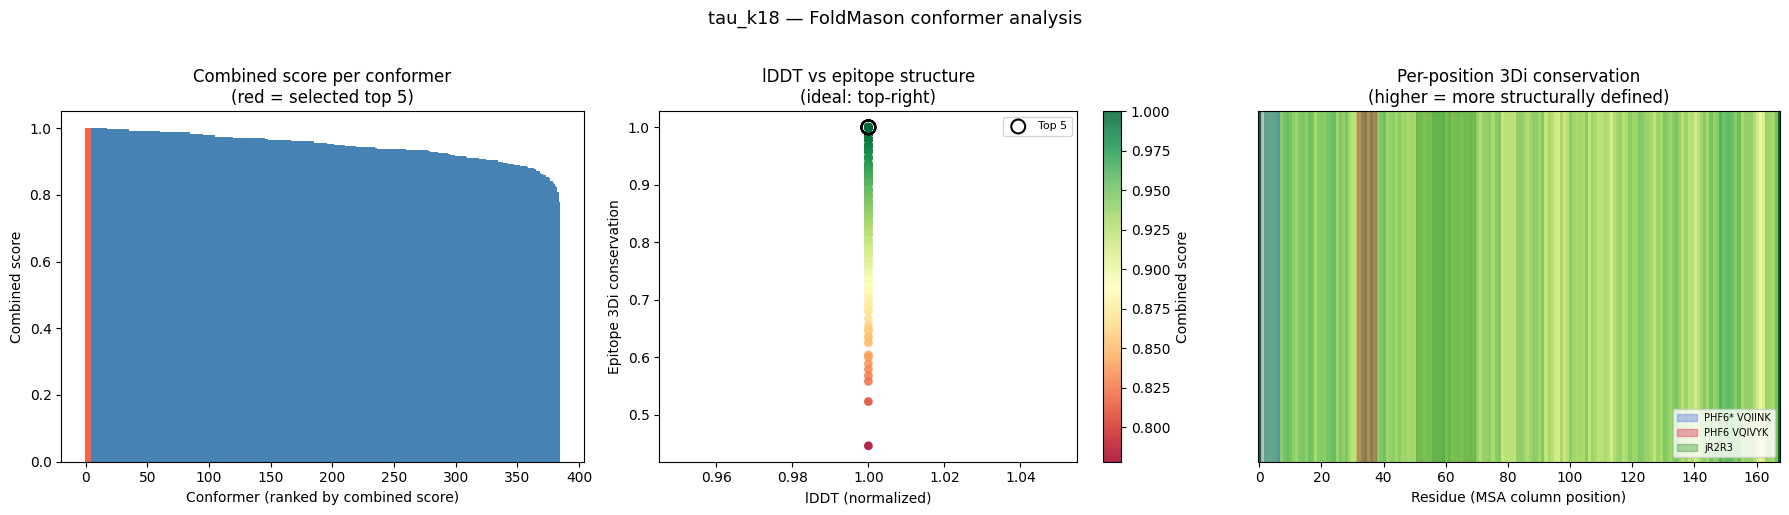

Saved foldmason_ranking.png


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_names   = set(df.iloc[:TOP_N]['name'])
epi_colors_map = {'PHF6* VQIINK': 'royalblue', 'PHF6 VQIVYK': 'crimson', 'jR2R3': 'forestgreen'}

# Plot 1: Combined score bar
ax = axes[0]
colors = ['tomato' if n in top_names else 'steelblue' for n in df['name']]
ax.bar(range(len(df)), df['combined'].values, color=colors, width=1.0, edgecolor='none')
ax.set_xlabel('Conformer (ranked by combined score)')
ax.set_ylabel('Combined score')
ax.set_title(f'Combined score per conformer\n(red = selected top {TOP_N})')

# Plot 2: lDDT vs epitope 3Di conservation
ax = axes[1]
sc = ax.scatter(df['lddt_norm'], df['epitope_struct'],
                c=df['combined'], cmap='RdYlGn', s=40, edgecolors='none', alpha=0.85)
plt.colorbar(sc, ax=ax, label='Combined score')
top_df = df.iloc[:TOP_N]
ax.scatter(top_df['lddt_norm'], top_df['epitope_struct'],
           s=100, facecolors='none', edgecolors='black', lw=1.5, label=f'Top {TOP_N}')
ax.set_xlabel('lDDT (normalized)')
ax.set_ylabel('Epitope 3Di conservation')
ax.set_title('lDDT vs epitope structure\n(ideal: top-right)')
ax.legend(fontsize=8)

# Plot 3: Per-position 3Di conservation heatmap
ax = axes[2]
cons_arr = []
for pos in range(n_cols_3di):
    col_chars = [s[pos] for s in di_seqs_list if pos < len(s)]
    non_gap   = [c for c in col_chars if c != '-']
    top_frac  = Counter(non_gap).most_common(1)[0][1] / len(non_gap) if non_gap else 0.0
    cons_arr.append(top_frac)
cons_arr = np.array(cons_arr)

ax.imshow(cons_arr.reshape(1, -1), cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
for start, end, label, *_ in EPITOPE_RANGES:
    color = epi_colors_map.get(label, 'gray')
    ax.axvspan(start - 1.5, end - 0.5, alpha=0.35, color=color, label=label)
ax.set_xlabel('Residue (MSA column position)')
ax.set_yticks([])
ax.set_title('Per-position 3Di conservation\n(higher = more structurally defined)')
ax.legend(fontsize=7, loc='lower right')

plt.suptitle(f'{PROTEIN_NAME} — FoldMason conformer analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.abspath(f'{PROTEIN_NAME}_foldmason_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved foldmason_ranking.png')

## 9. Copy top conformers to binder-ready folder

In [54]:
binder_dir = os.path.abspath(f'{PROTEIN_NAME}_binder_ready')
os.makedirs(binder_dir, exist_ok=True)

csv_path = os.path.abspath(f'{PROTEIN_NAME}_conformer_ranking.csv')
df.to_csv(csv_path)

copied = []
for rank_idx, row in df.iloc[:TOP_N].iterrows():
    stem = os.path.splitext(row['name'])[0]
    candidates = (glob.glob(os.path.join(filtered_dir, f'{stem}.pdb')) +
                  glob.glob(os.path.join(filtered_dir, f'*{stem}*.pdb')))
    if not candidates:
        print(f'  WARNING: PDB not found for {row["name"]}')
        continue
    src = candidates[0]
    dst = os.path.join(binder_dir, f'rank{rank_idx:02d}_{os.path.basename(src)}')
    shutil.copy2(src, dst)
    copied.append(dst)
    print(f'  Rank {rank_idx}: {row["name"]}  '
          f'combined={row["combined"]}  lDDT={row["lddt_raw"]}  epitope={row["epitope_struct"]}')

print(f'\n{len(copied)} conformers ready in: {binder_dir}/')
print('Next: upload these PDBs one at a time to NB02b (BindCraft) or run NB02c (Forge)')

  Rank 1: filtered_0256  combined=1.0  lDDT=None  epitope=1.0
  Rank 2: filtered_0331  combined=1.0  lDDT=None  epitope=1.0
  Rank 3: filtered_0372  combined=1.0  lDDT=None  epitope=1.0
  Rank 4: filtered_0202  combined=1.0  lDDT=None  epitope=1.0
  Rank 5: filtered_0019  combined=1.0  lDDT=None  epitope=1.0

5 conformers ready in: /content/drive/MyDrive/CHEM_280/results/nb01_output/tau_k18_binder_ready/
Next: upload these PDBs one at a time to NB02b (BindCraft) or run NB02c (Forge)


In [55]:
import zipfile

zip_name = os.path.abspath(f'{PROTEIN_NAME}_phase1_results.zip')

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Starling trajectory
    zf.write(pdb_file, os.path.basename(pdb_file))
    zf.write(xtc_file, os.path.basename(xtc_file))
    # Filtered frames
    for fn in sorted(os.listdir(filtered_dir)):
        zf.write(os.path.join(filtered_dir, fn), os.path.join('filtered_frames', fn))
    # Binder-ready conformers
    for fn in sorted(os.listdir(binder_dir)):
        zf.write(os.path.join(binder_dir, fn), os.path.join('binder_ready', fn))
    # FoldMason MSA files
    for path in [msa_aa_path, msa_3di_path]:
        if os.path.exists(path):
            zf.write(path, os.path.basename(path))
    # FoldMason JSON report (contains lDDT)
    if os.path.exists(json_path): # Changed to json_path
        zf.write(json_path, os.path.basename(json_path))
    # CSV and plots
    zf.write(csv_path, os.path.basename(csv_path))
    for png in [os.path.abspath(f'{PROTEIN_NAME}_ensemble_analysis.png'),
                os.path.abspath(f'{PROTEIN_NAME}_foldmason_ranking.png')]:
        if os.path.exists(png):
            zf.write(png, os.path.basename(png))

print(f'Zip ready: {os.path.basename(zip_name)}  ({os.path.getsize(zip_name)//1024} KB)')
print('Contents: Starling trajectory | filtered_frames/ | binder_ready/ | '
      'FoldMason AA+3Di MSA | JSON report | ranking CSV | plots') # Updated description

try:
    from google.colab import files as _colab_files
    _colab_files.download(zip_name)
except ImportError:
    print(f'Not in Colab — file saved at: {zip_name}')

Zip ready: tau_k18_phase1_results.zip  (2415 KB)
Contents: Starling trajectory | filtered_frames/ | binder_ready/ | FoldMason AA+3Di MSA | JSON report | ranking CSV | plots


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

**Trim guide** (for the next Starling run):
- AFRC Plot B (Section 5): peaks in per-residue deviation at N or C terminus → cut those residues
- FoldMason Plot 3 (Section 8): low 3Di conservation at termini → same signal, structural confirmation
- Both plots pointing to the same terminal residues = high confidence trim

**Production run**: set `N_CONFORMERS = 400` in the config cell after trimming is confirmed.

**What's in the zip**:
| Folder/File | Contents |
|-------------|----------|
| `*_STARLING.pdb/xtc` | Full Starling trajectory |
| `filtered_frames/` | Rg-filtered PDB frames |
| `binder_ready/` | Top N conformers for binder design |
| `*_foldmason_msa_aa.fa` | Structural AA MSA |
| `*_foldmason_msa_3di.fa` | 3Di token MSA |
| `*_foldmason.json` | FoldMason lDDT JSON |
| `*_conformer_ranking.csv` | Full ranked conformer table |
| `*_ensemble_analysis.png` | AFRC deviation plots |
| `*_foldmason_ranking.png` | lDDT + epitope + 3Di conservation plots |